# Van der Pol polytope reachable-set synthesis with `ReachiLQR`

The polytope counterpart of `vdp.py`. The reachable set is a **polytope**
$\{x : \ell y \le H(x-\mathring{x}) \le uy\}$ carried by the `AdjointEmbedding`,
which evolves the shaping matrix $H$ together with a maintained inverse $H^{+}$
and left-null basis $N$ as auxiliary state. We give that embedding a
**hypercontrol** $U$ that enters the $H$ dynamics *and* the offset dynamics
(required for soundness — $U$ perturbs $\dot H$, and the offset-growth bound
depends on $\dot H$), propagating to $H^{+}$ and $N$ so $H^{+}H=I$, $NH=0$:

$$ \dot H = u_0 + u^\* + U,\quad \dot H^{+} = -H^{+}\dot H H^{+},\quad
   \dot N = -N\dot H H^{+}, $$

with $u_0 = -H\,\partial_x f$ (adjoint) and $U,u^\*$ also appearing in the
offset bound. We use a **square, invertible** $H$ ($H^{+}=H^{-1}$, $N$ empty) —
a parallelotope. The cost is the log-volume,
$-\log\det\big((H/s)^\top(H/s)\big)$, $s_i=(uy_i-\ell y_i)/2$ (row-wise).

**What this demonstrates (and its limit).** The synthesis is *sound*: the
enclosure (and its `embedding.iover` box) contains the true reachable set. The
pure adjoint ($U=0$) keeps the set bounded only to $t\approx1.6$; the
hypercontrol extends that to $t\approx2.5$ while tightening the set. A **square
parallelotope cannot reach the full $t=7$** horizon of `vdp.py` — its offset
blows up around $t\approx2.6$ no matter the schedule (the nonlinear-residual
feedback wins). Adding faces does *not* help here: an octagon (4 directions,
non-square $H$, nonempty $N$) was tried with both a log-det-Gram cost and a
refined-facet boundary-volume cost, and reaches a *shorter* horizon (~160) — the
extra faces' offsets blow up earlier, and since the rollout freezes when *any*
face exceeds `Jmax`, they cap the horizon. For VDP the square parallelotope is
the better representation; the full $t=7$ horizon would need a different
embedding or offset bound, not just more faces.

**Why a custom loop.** The iLQR step here needs *much* heavier LM damping than
the normotope ($R\approx200$), and the rollout must end in the smooth regime,
not on the blow-up cliff. So we walk `ifinal` out: start with a tight `Jmax`
(keeps the rollout off the cliff so tightening works), revert to the best
iterate, and loosen `Jmax` when progress stalls. `run()`'s schedule covers
$(R,\text{revert})$ but not `Jmax`, so we drive `iterate()` directly.

In [5]:
import os
import time

import jax
import jax.numpy as jnp
import numpy as onp
from typing import ClassVar
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import immrax as irx
from immrax.parametric import ReachiLQR, AdjointEmbedding, Polytope
from immrax.inclusion import Permutation, icentpert
from immrax.utils import draw_iarray

try:
    HERE = os.path.dirname(__file__)
except NameError:
    HERE = os.getcwd()
OUT = os.path.join(HERE, "out")
os.makedirs(OUT, exist_ok=True)

## The Van der Pol system

$\dot x_1 = x_2,\ \dot x_2 = \mu(1-x_1^2)x_2 - x_1$ with $\mu=1$.

In [6]:
class VanDerPol(irx.System):
    xlen: ClassVar[int] = 2
    mu: float = 1.0

    def f(self, t, x):
        return jnp.array([x[1], self.mu * (1 - x[0] ** 2) * x[1] - x[0]])


sys = VanDerPol()

## Initial polytope

A square axis-aligned box around $\mathring{x}=(-2,0)$: $H=I$, half-width
$0.0125$. Square invertible $H \Rightarrow H^{+}=H^{-1}$, $N$ empty. Horizon
$t\in[0,2.5]$, $N=250$ (just inside the $t\approx2.6$ wall).

In [7]:
x0 = jnp.array([-2.0, 0.0])
half = 0.0125
pt0 = Polytope.from_interval(icentpert(x0, half * jnp.ones(2)))
alpha_p0 = jnp.linalg.inv(pt0.alpha)  # H+ = H^{-1}
N0 = jnp.zeros((0, 2))  # empty left-null basis (square invertible H)
N = 250
dt = 0.01

## Cost: log-volume of the parallelotope

$\Phi = -\log\det\big((H/s)^\top(H/s)\big)$, $s_i=(uy_i-\ell y_i)/2$.

In [8]:
def terminal_cost(pt):
    K = len(pt.y) // 2
    ly, uy = -pt.y[:K], pt.y[K:]
    scale = (uy - ly) / 2  # per-row half-width
    A = pt.alpha / scale[:, None]  # row-wise divide
    return -jnp.linalg.slogdet(A.T @ A)[1]


def running_cost(t, pt, U):
    return jnp.array(0.0)

## Embedding and the iLQR solver

In [9]:
embedding = AdjointEmbedding(sys, alpha_p0, N0, permutation=Permutation(range(3)))
ilqr = ReachiLQR(
    embedding=embedding,
    pt0=pt0,
    terminal_cost=terminal_cost,
    running_cost=running_cost,
    t0=0.0,
    tf=N * dt,
    N=N,
    DDP=False,
    solver="euler",
    dt=dt,
    track_iover=True,
)

print(f"initial cost = {terminal_cost(pt0): .4f}")
print(f"Xlen={ilqr.Xlen}  Ulen={ilqr.Ulen}  N={ilqr.N}  track_iover={ilqr.track_iover}")

/tmp/claude-1000/ipykernel_1747757/2776518603.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  embedding = AdjointEmbedding(sys, alpha_p0, N0, permutation=Permutation(range(3)))


initial cost = -17.5281
Xlen=14  Ulen=4  N=250  track_iover=True


## Monte Carlo validation

40 rollouts from the boundary of the initial box for an inner reference.

In [10]:
def box_boundary(key, M, c, h):
    s = jax.random.uniform(key, (M, 2), minval=-1.0, maxval=1.0)
    s = s / jnp.max(jnp.abs(s), axis=1, keepdims=True)  # project to the box boundary
    return c + h * s


mc_x0s = box_boundary(jax.random.PRNGKey(0), 40, x0, half)


@jax.jit
def rollout(x):
    def step(carry, _):
        n = carry + dt * sys.f(0.0, carry)
        return n, n

    _, xs = jax.lax.scan(step, x, None, length=N)
    return jnp.vstack([x, xs])


mc_trajs = jax.vmap(rollout)(mc_x0s)

## Solving — adaptive `Jmax` walk-out

Heavy damping `R=200`, revert-to-best every 5 iterations, and a `Jmax` that
starts tight (`-13`) and loosens by 1 (up to `-4`) whenever the best `ifinal`
stalls — walking the horizon out past the cliff as the set tightens.

In [11]:
R = 200.0
gamma = 0.5
ITERS = 600
Jmax = -13.0
JMAX_CAP = -4.0

Us = ilqr.initial_controls()
l_traj, K_traj = ilqr.initial_gains()
iover = ilqr.initial_iover()
best = {"ifinal": -1, "cost": jnp.inf, "Us": Us, "iover": iover, "idx": 0}
states = []
stall = 0

t_jit = time.time()
ilqr.setup()
print(f"JIT compile: {time.time() - t_jit:.1f}s")

t_start = time.time()
for i in range(ITERS):
    revert = i % 5 == 4
    res = ilqr.iterate(Us, l_traj, K_traj, R, gamma=gamma, Jmax=Jmax, iover=iover)
    iover = res.iover
    f, c = int(res.ifinal), float(res.cost_final)
    states.append(
        {"state_vec": onp.asarray(res.pert_traj), "ifinal": f, "cost": c, "Jmax": Jmax}
    )
    if (f, -c) > (best["ifinal"], -best["cost"]):
        best = {"ifinal": f, "cost": c, "Us": res.Us_new, "iover": res.iover, "idx": i}
        stall = 0
    else:
        stall += 1
    Us = best["Us"] if revert else res.Us_new
    l_traj, K_traj = res.l_traj, res.K_traj
    if stall >= 40 and best["ifinal"] < N and Jmax < JMAX_CAP:
        Jmax = min(Jmax + 1.0, JMAX_CAP)
        stall = 0
    if i % 50 == 0:
        print(f"  i={i:>3d}  Jmax={Jmax:>5.0f}  best_ifinal={best['ifinal']:>4d}  best_cost={best['cost']: .3f}")

print(f"Elapsed (excl. JIT): {time.time() - t_start:.1f}s")
print(f"Best: ifinal={best['ifinal']}/{N}  cost={best['cost']:.3f}")

overall_best = best["idx"]
iover_lo = onp.asarray(best["iover"].lower)
iover_up = onp.asarray(best["iover"].upper)

JIT compile: 7.0s
  i=  0  Jmax=  -13  best_ifinal= 156  best_cost=-13.803
  i= 50  Jmax=  -12  best_ifinal= 235  best_cost=-12.197
  i=100  Jmax=  -11  best_ifinal= 239  best_cost=-11.209
  i=150  Jmax=  -10  best_ifinal= 242  best_cost=-10.317
  i=200  Jmax=   -9  best_ifinal= 245  best_cost=-9.242
  i=250  Jmax=   -8  best_ifinal= 247  best_cost=-8.385
  i=300  Jmax=   -7  best_ifinal= 249  best_cost=-7.370
  i=350  Jmax=   -6  best_ifinal= 250  best_cost=-6.784
  i=400  Jmax=   -6  best_ifinal= 250  best_cost=-6.784
  i=450  Jmax=   -6  best_ifinal= 250  best_cost=-6.784
  i=500  Jmax=   -6  best_ifinal= 250  best_cost=-6.784
  i=550  Jmax=   -6  best_ifinal= 250  best_cost=-6.784
Elapsed (excl. JIT): 5.2s
Best: ifinal=250/250  cost=-6.784


## Soundness check

The whole point of a *certified* reach set: every Monte-Carlo sample must lie
inside the synthesized polytope (and its `iover` box) at each step. A
containment value $\le 0$ (up to Euler/float noise) means the enclosure is
sound.

In [12]:
_sv = states[overall_best]["state_vec"]
_ifin = states[overall_best]["ifinal"]
_worst_poly = -onp.inf
_worst_box = -onp.inf
for k in range(0, _ifin + 1):
    _pt, _aux = ilqr._unflatten(jnp.asarray(_sv[k]))
    _box = embedding.iover((_pt, _aux))
    _pts = mc_trajs[:, k, :]
    _worst_poly = max(_worst_poly, float(jnp.max(jax.vmap(lambda x: _pt.g(x) - _pt.y)(_pts))))
    _worst_box = max(_worst_box, float(jnp.max(jnp.maximum(_box.lower[None] - _pts, _pts - _box.upper[None]))))
print(f"worst polytope containment violation (<=0 sound): {_worst_poly:.2e}")
print(f"worst iover-box  containment violation (<=0 sound): {_worst_box:.2e}")

worst polytope containment violation (<=0 sound): 1.11e-16
worst iover-box  containment violation (<=0 sound): 0.00e+00


## Convergence frames

Snapshots of the parallelotope tube against the Monte-Carlo samples (red),
reconstructing each step's `Polytope` from the flattened state.

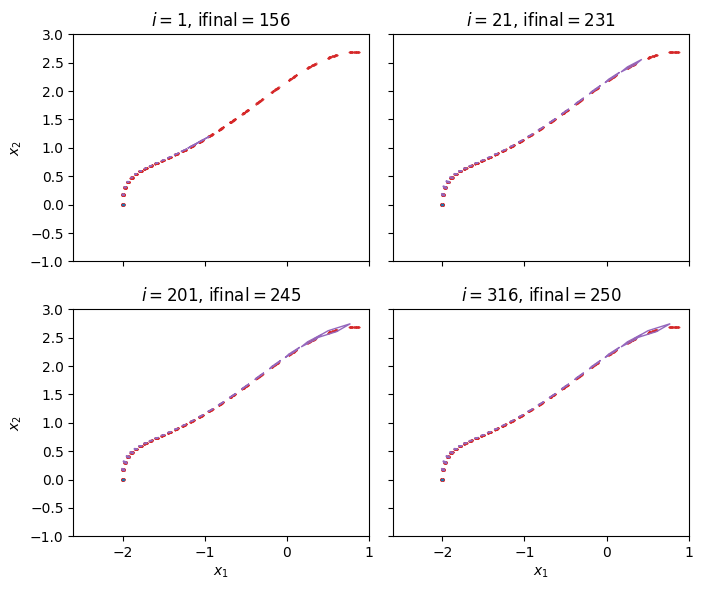

In [13]:
PLOT_EVERY = 10


def poly_at(state_vec, k):
    pt, _aux = ilqr._unflatten(jnp.asarray(state_vec[k]))
    return pt


def plot_i(i, ax, color="tab:purple"):
    ax.clear()
    ax.scatter(mc_trajs[:, ::PLOT_EVERY, 0], mc_trajs[:, ::PLOT_EVERY, 1],
               color="tab:red", s=0.1)
    pt0.plot_projection(ax, color="tab:blue")
    sv = states[i]["state_vec"]
    for k in range(PLOT_EVERY, states[i]["ifinal"], PLOT_EVERY):
        poly_at(sv, k).plot_projection(ax, color=color)
    ax.set_title(f"$i={i + 1}$, ifinal$={states[i]['ifinal']}$")
    ax.set_xlim(-2.6, 1.0)
    ax.set_ylim(-1.0, 3.0)


frames = [0, 20, ITERS // 3, overall_best]
fig, axs = plt.subplots(2, 2, figsize=(7, 6), sharex=True, sharey=True)
for frame, ax in zip(frames, axs.flatten()):
    plot_i(frame, ax)
axs[0, 0].set_ylabel("$x_2$")
axs[1, 0].set_ylabel("$x_2$")
axs[1, 0].set_xlabel("$x_1$")
axs[1, 1].set_xlabel("$x_1$")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(OUT, f"vdp_poly_frames.{ext}"), dpi=150)
plt.show()

## Cost along the trajectory

Terminal log-volume along the best iterate's tube.

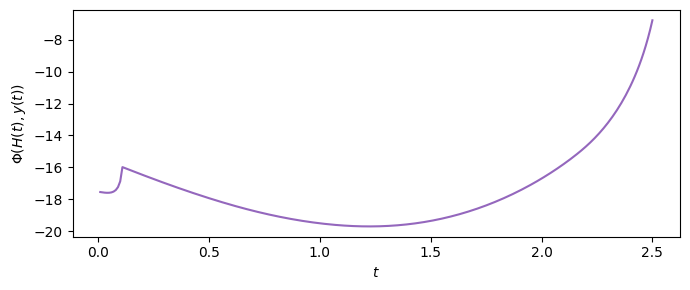

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
sv = states[overall_best]["state_vec"]
ifin = states[overall_best]["ifinal"]
ts = onp.arange(1, ifin + 1) * dt
costs = onp.array([float(terminal_cost(poly_at(sv, k))) for k in range(1, ifin + 1)])
ax.plot(ts, costs, color="tab:purple")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\Phi(H(t), y(t))$")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(OUT, f"vdp_poly_cost.{ext}"), dpi=150)
plt.show()

## `iover` comparison

Best iterate's parallelotopes (purple), each one's per-step axis-aligned hull
`embedding.iover((pt, aux))` (orange), and the accumulated cross-iteration
intersection (green), all soundly containing the Monte-Carlo truth (red).

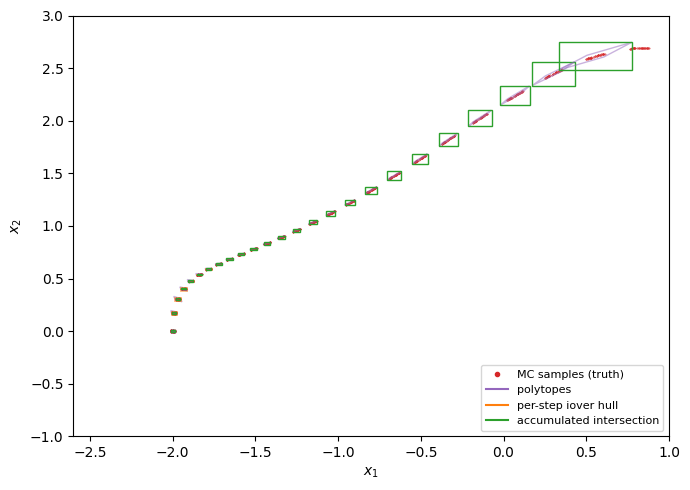

In [15]:
def draw(ax, every=10):
    ax.scatter(mc_trajs[:, ::every, 0], mc_trajs[:, ::every, 1],
               color="tab:red", s=0.1, zorder=1)
    pt0.plot_projection(ax, color="tab:blue")
    for k in range(0, ifin, every):
        pt, aux = ilqr._unflatten(jnp.asarray(sv[k]))
        pt.plot_projection(ax, color="tab:purple", alpha=0.5)
        draw_iarray(ax, embedding.iover((pt, aux)), ec="tab:orange", lw=0.5, alpha=0.7)
        if onp.isfinite([iover_lo[k, 0], iover_lo[k, 1],
                         iover_up[k, 0], iover_up[k, 1]]).all():
            draw_iarray(ax, irx.interval(iover_lo[k], iover_up[k]), ec="tab:green", lw=1.0)


fig, ax = plt.subplots(figsize=(7, 5))
draw(ax)
ax.set_xlim(-2.6, 1.0)
ax.set_ylim(-1.0, 3.0)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(
    handles=[
        Line2D([0], [0], color="tab:red", marker="o", ls="", ms=3, label="MC samples (truth)"),
        Line2D([0], [0], color="tab:purple", label="polytopes"),
        Line2D([0], [0], color="tab:orange", label="per-step iover hull"),
        Line2D([0], [0], color="tab:green", label="accumulated intersection"),
    ],
    loc="lower right",
    fontsize=8,
)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(OUT, f"vdp_poly_iover_compare.{ext}"), dpi=150)
plt.show()